# Propagator Evaluation — Results Analysis

Full analysis of all 6 experimental phases.
Source: `experiments/propagator_eval/RESULTS_REPORT.md`

| Phase | Content |
|-------|---------|
| 1 | Cora intrinsic feature quality |
| 2 | Ablation studies (alpha, epsilon, hop depth) |
| 3 | Cora downstream node classification |
| 4 | Homophilic reproduction (Citeseer + Pubmed) |
| 5 | OGBN-Arxiv scalability (intrinsic only) |
| 6 | Heterophily stress test (Texas + Wisconsin) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'legend.fontsize': 8,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': '#cccccc',
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
})

COLORS = {
    'APPNP':     '#2A9D8F',
    'Chebyshev': '#E76F51',
    'Diffusion': '#264653',
    'Adjacency': '#E9C46A',
    'Asym. RW':  '#F4A261',
}
MARKERS = {
    'APPNP':     'o',
    'Chebyshev': 's',
    'Diffusion': '^',
    'Adjacency': 'D',
    'Asym. RW':  'v',
}
OPS    = ['APPNP', 'Chebyshev', 'Diffusion', 'Adjacency', 'Asym. RW']
FIG_S  = (3.8, 2.8)
FIG_W  = (6.5, 2.8)

import pathlib as _pl
OUTDIR = str(_pl.Path('/home/bosho/FP/experiments/propagator_eval/figures'))

print('Setup complete.')
print('Saving figures to:', OUTDIR)


Setup complete.
Saving figures to: /home/bosho/FP/experiments/propagator_eval/figures


## Phase 1 — Cora Intrinsic Feature Quality

Metrics measure how well propagated features reconstruct oracle full-graph features.

In [2]:
# Table 1.1 — intrinsic metrics by operator and beta (Cora)
p1 = pd.DataFrame({
    'Operator':   ['Heat Kernel', 'APPNP','APPNP','APPNP',
                   'Chebyshev','Chebyshev','Chebyshev',
                   'Diffusion','Diffusion','Diffusion',
                   'Adjacency','Adjacency','Adjacency',
                   'Asym. RW','Asym. RW','Asym. RW'],
    'Beta':       [10000, 1,10,10000, 1,10,10000, 1,10,10000, 1,10,10000, 1,10,10000],
    'MSE_mean':   [0.01231,0.01294,0.01299,0.01299, 0.01316,0.01324,0.01325,
                   0.01328,0.01335,0.01334, 0.01391,0.01399,0.01400,
                   0.01594,0.01598,0.01602],
    'MSE_std':    [0.00000,0.00002,0.00002,0.00002, 0.00003,0.00002,0.00002,
                   0.00002,0.00002,0.00002, 0.00003,0.00003,0.00002,
                   0.00001,0.00005,0.00004],
    'CosSim':     [0.2068,0.2215,0.2192,0.2183, 0.2424,0.2397,0.2386,
                   0.2226,0.2199,0.2189, 0.2265,0.2245,0.2237,
                   0.2225,0.2205,0.2196],
    'RecovRatio': [0.0343,-0.0151,-0.0165,-0.0169, -0.0325,-0.0356,-0.0373,
                   -0.0425,-0.0442,-0.0444, -0.0918,-0.0945,-0.0962,
                   -0.2509,-0.2502,-0.2541],
    'ConvRate':   [1.00,1.00,1.00,1.00, 0.00,0.00,0.00, 0.00,0.00,0.00,
                   0.97,0.97,0.97, 1.00,1.00,1.00],
    'WallTime_s': [0.21,2.33,2.27,2.37, 29.87,345.31,725.85,
                   139.64,141.26,109.40, 115.60,119.22,121.56,
                   101.08,104.55,104.30],
})

# Format as ±
def pm(row, col): return f"{row[col+'_mean']:.5f} ± {row[col+'_std']:.5f}"

p1_display = p1.copy()
p1_display['MSE'] = p1.apply(lambda r: pm(r, 'MSE'), axis=1)
p1_display = p1_display[['Operator','Beta','MSE','CosSim','RecovRatio','ConvRate','WallTime_s']]
p1_display.columns = ['Operator','Beta','MSE (±std)','CosSim','RecovRatio','ConvRate','WallTime (s)']
display(p1_display)


,Operator,Beta,MSE (±std),CosSim,RecovRatio,ConvRate,WallTime (s)
0,Heat Kernel,10000,0.01231 ± 0.00000,0.2068,0.0343,1.0000,0.2100
1,APPNP,1,0.01294 ± 0.00002,0.2215,-0.0151,1.0000,2.3300
2,APPNP,10,0.01299 ± 0.00002,0.2192,-0.0165,1.0000,2.2700
3,APPNP,10000,0.01299 ± 0.00002,0.2183,-0.0169,1.0000,2.3700
4,Chebyshev,1,0.01316 ± 0.00003,0.2424,-0.0325,0.0000,29.8700
5,Chebyshev,10,0.01324 ± 0.00002,0.2397,-0.0356,0.0000,345.3100
6,Chebyshev,10000,0.01325 ± 0.00002,0.2386,-0.0373,0.0000,725.8500
7,Diffusion,1,0.01328 ± 0.00002,0.2226,-0.0425,0.0000,139.6400
8,Diffusion,10,0.01335 ± 0.00002,0.2199,-0.0442,0.0000,141.2600
9,Diffusion,10000,0.01334 ± 0.00002,0.2189,-0.0444,0.0000,109.4000


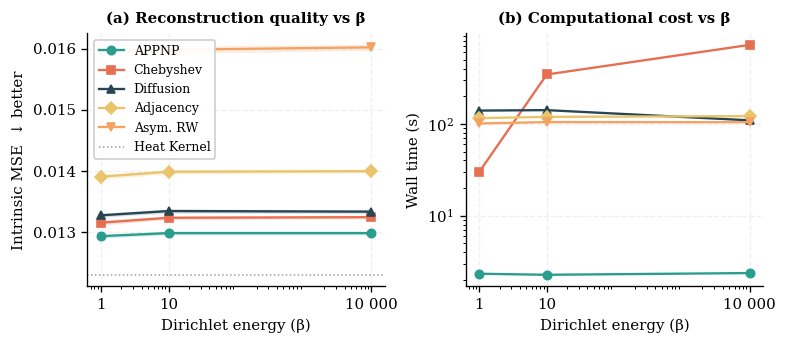

Key finding: beta has negligible effect on intrinsic quality; Chebyshev wall-time explodes at high beta.


In [3]:
# Figure 4 (secondary): MSE vs Beta per operator
# Figure 5 (secondary): Wall Time vs Beta per operator

betas = [1, 10, 10000]
fig, axes = plt.subplots(1, 2, figsize=FIG_W)

for op in OPS:
    sub = p1[p1['Operator'] == op].sort_values('Beta')
    mse_vals = sub['MSE_mean'].values
    wt_vals  = sub['WallTime_s'].values
    mse_std  = sub['MSE_std'].values
    axes[0].plot([1,10,10000], mse_vals, marker=MARKERS[op], color=COLORS[op],
                 label=op, linewidth=1.4, markersize=5)
    axes[0].fill_between([1,10,10000], mse_vals-mse_std, mse_vals+mse_std,
                          color=COLORS[op], alpha=0.12)
    axes[1].plot([1,10,10000], wt_vals, marker=MARKERS[op], color=COLORS[op],
                 label=op, linewidth=1.4, markersize=5)

# Heat Kernel reference line (beta=10000 only)
axes[0].axhline(0.01231, color='#999', linewidth=0.9, linestyle=':', label='Heat Kernel')

for ax in axes:
    ax.set_xscale('log')
    ax.set_xticks([1, 10, 10000])
    ax.set_xticklabels(['1', '10', '10 000'])
    ax.set_xlabel('Dirichlet energy (β)')

axes[0].set_ylabel('Intrinsic MSE  ↓ better')
axes[0].set_title('(a) Reconstruction quality vs β')
axes[1].set_ylabel('Wall time (s)')
axes[1].set_yscale('log')
axes[1].set_title('(b) Computational cost vs β')

axes[0].legend(loc='upper left', fontsize=7.5)
fig.tight_layout(pad=0.5)
plt.savefig(f'{OUTDIR}/fig_ph1_mse_walltime_vs_beta.pdf')
plt.savefig(f'{OUTDIR}/fig_ph1_mse_walltime_vs_beta.png', dpi=300)
plt.show()
print('Key finding: beta has negligible effect on intrinsic quality; Chebyshev wall-time explodes at high beta.')


## Phase 2 — Ablation Studies (Cora, β = 10 000)

Sweeps over APPNP teleport probability α, Diffusion convergence tolerance ε, and hop depth L.

In [4]:
# 2a — APPNP alpha sweep
p2_alpha = pd.DataFrame({
    'Alpha': [0.05, 0.10, 0.20],
    'MSE':   [0.01339, 0.01299, 0.01255],
    'MSE_std':[0.00002, 0.00002, 0.00002],
    'CosSim': [0.2209, 0.2183, 0.2136],
    'RecovRatio': [-0.0481, -0.0169, 0.0176],
    'AvgIters': [38.3, 32.4, 24.3],
    'ConvRate': [1.00, 1.00, 1.00],
    'WallTime_s': [1.08, 0.92, 0.71],
})

# 2b — Diffusion tolerance sweep
p2_eps = pd.DataFrame({
    'Tolerance': ['1e-02', '1e-03', '1e-04'],
    'MSE':   [0.01334]*3,
    'CosSim': [0.2189]*3,
    'AvgIters': [100.0]*3,
    'ConvRate': [0.00]*3,
    'WallTime_s': [3.70, 3.69, 3.69],
})

# 2c — Hop depth
p2_hop = pd.DataFrame({
    'Hop':      [1, 2, 1, 2],
    'Operator': ['Adjacency','Adjacency','Diffusion','Diffusion'],
    'MSE':      [0.01400, 0.01290, 0.01334, 0.01257],
    'MSE_std':  [0.00002, 0.00001, 0.00002, 0.00001],
    'CosSim':   [0.2237, 0.2423, 0.2189, 0.2123],
    'RecovRatio': [-0.0962, -0.0095, -0.0444, 0.0160],
    'WallTime_s': [2.39, 4.42, 3.70, 11.55],
})

print('=== 2a  APPNP Alpha Sweep ===')
display(p2_alpha)
print('\n=== 2b  Diffusion Tolerance Sweep ===')
display(p2_eps)
print('\n=== 2c  Hop Depth (L=1 vs L=2) ===')
display(p2_hop)


=== 2a  APPNP Alpha Sweep ===


,Alpha,MSE,MSE_std,CosSim,RecovRatio,AvgIters,ConvRate,WallTime_s
0,0.0500,0.0134,0.0000,0.2209,-0.0481,38.3000,1.0000,1.0800
1,0.1000,0.0130,0.0000,0.2183,-0.0169,32.4000,1.0000,0.9200
2,0.2000,0.0126,0.0000,0.2136,0.0176,24.3000,1.0000,0.7100



=== 2b  Diffusion Tolerance Sweep ===


,Tolerance,MSE,CosSim,AvgIters,ConvRate,WallTime_s
0,1e-02,0.0133,0.2189,100.0000,0.0000,3.7000
1,1e-03,0.0133,0.2189,100.0000,0.0000,3.6900
2,1e-04,0.0133,0.2189,100.0000,0.0000,3.6900



=== 2c  Hop Depth (L=1 vs L=2) ===


,Hop,Operator,MSE,MSE_std,CosSim,RecovRatio,WallTime_s
0,1,Adjacency,0.0140,0.0000,0.2237,-0.0962,2.3900
1,2,Adjacency,0.0129,0.0000,0.2423,-0.0095,4.4200
2,1,Diffusion,0.0133,0.0000,0.2189,-0.0444,3.7000
3,2,Diffusion,0.0126,0.0000,0.2123,0.0160,11.5500


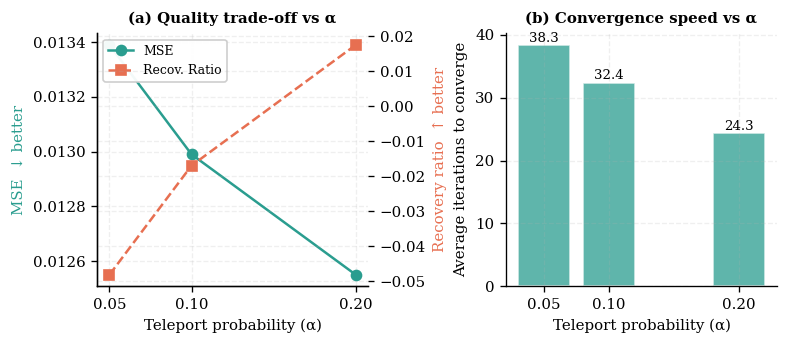

Higher α → lower MSE and fewer iterations, but reduced cosine similarity (less propagation).


In [5]:
# Two-panel: APPNP alpha sweep
fig, axes = plt.subplots(1, 2, figsize=FIG_W)

# Panel (a): MSE and Recovery Ratio vs alpha
ax = axes[0]
ax2 = ax.twinx()
ax.plot(p2_alpha['Alpha'], p2_alpha['MSE'], 'o-', color=COLORS['APPNP'], label='MSE', linewidth=1.5)
ax2.plot(p2_alpha['Alpha'], p2_alpha['RecovRatio'], 's--', color='#E76F51', label='Recov. Ratio', linewidth=1.5)
ax.set_xlabel('Teleport probability (α)')
ax.set_ylabel('MSE  ↓ better', color=COLORS['APPNP'])
ax2.set_ylabel('Recovery ratio  ↑ better', color='#E76F51')
ax.set_xticks(p2_alpha['Alpha'])
ax.set_title('(a) Quality trade-off vs α')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=7.5)

# Panel (b): Avg Iterations vs alpha
ax = axes[1]
ax.bar(p2_alpha['Alpha'], p2_alpha['AvgIters'], color=COLORS['APPNP'],
       width=0.04, alpha=0.75, edgecolor='white')
ax.set_xlabel('Teleport probability (α)')
ax.set_ylabel('Average iterations to converge')
ax.set_xticks(p2_alpha['Alpha'])
ax.set_title('(b) Convergence speed vs α')
for x, y in zip(p2_alpha['Alpha'], p2_alpha['AvgIters']):
    ax.text(x, y + 0.5, f'{y:.1f}', ha='center', fontsize=8)

fig.tight_layout(pad=0.5)
plt.savefig(f'{OUTDIR}/fig_ph2_appnp_alpha.pdf')
plt.savefig(f'{OUTDIR}/fig_ph2_appnp_alpha.png', dpi=300)
plt.show()
print('Higher α → lower MSE and fewer iterations, but reduced cosine similarity (less propagation).')


## Phase 3 — Cora Downstream Node Classification

Gap = (acc − zero_hop) / (oracle − zero_hop). Higher is better.

In [6]:
# Zero-hop and oracle references
p3_ref = pd.DataFrame({
    'Backbone': ['GCN','GCN','GAT','GAT'],
    'Beta': [1, 10000, 1, 10000],
    'ZeroHop_acc': [0.6690, 0.6038, 0.4058, 0.4292],
    'ZeroHop_std': [0.0092, 0.0162, 0.0410, 0.0236],
    'Oracle_acc':  [0.7938, 0.8120, 0.7639, 0.7857],
    'Oracle_std':  [0.0038, 0.0050, 0.0079, 0.0096],
    'OracleGap':   [0.1248, 0.2082, 0.3581, 0.3565],
})

# GCN results
p3_gcn = pd.DataFrame({
    'Operator':  OPS,
    'Acc_b1':    [0.7672, 0.7840, 0.7622, 0.7738, 0.7690],
    'Std_b1':    [0.0133, 0.0096, 0.0139, 0.0127, 0.0062],
    'Gap_b1':    [0.791,  0.924,  0.750,  0.843,  0.801],
    'Acc_b10k':  [0.7105, 0.7205, 0.7048, 0.7174, 0.7063],
    'Std_b10k':  [0.0185, 0.0071, 0.0168, 0.0130, 0.0154],
    'Gap_b10k':  [0.508,  0.570,  0.486,  0.546,  0.504],
})

# GAT results
p3_gat = pd.DataFrame({
    'Operator':  OPS,
    'Acc_b1':    [0.6680, 0.7006, 0.6480, 0.6874, 0.6604],
    'Std_b1':    [0.0148, 0.0251, 0.0144, 0.0226, 0.0100],
    'Gap_b1':    [0.732,  0.825,  0.676,  0.788,  0.709],
    'Acc_b10k':  [0.6676, 0.6898, 0.6506, 0.6800, 0.6736],
    'Std_b10k':  [0.0284, 0.0217, 0.0322, 0.0268, 0.0302],
    'Gap_b10k':  [0.669,  0.731,  0.623,  0.704,  0.687],
})

print('=== Reference: Zero-hop and Oracle ===')
display(p3_ref)
print('\n=== Table 3.1  GCN Backbone ===')
display(p3_gcn)
print('\n=== Table 3.2  GAT Backbone ===')
display(p3_gat)


=== Reference: Zero-hop and Oracle ===


,Backbone,Beta,ZeroHop_acc,ZeroHop_std,Oracle_acc,Oracle_std,OracleGap
0,GCN,1,0.6690,0.0092,0.7938,0.0038,0.1248
1,GCN,10000,0.6038,0.0162,0.8120,0.0050,0.2082
2,GAT,1,0.4058,0.0410,0.7639,0.0079,0.3581
3,GAT,10000,0.4292,0.0236,0.7857,0.0096,0.3565



=== Table 3.1  GCN Backbone ===


,Operator,Acc_b1,Std_b1,Gap_b1,Acc_b10k,Std_b10k,Gap_b10k
0,APPNP,0.7672,0.0133,0.7910,0.7105,0.0185,0.5080
1,Chebyshev,0.7840,0.0096,0.9240,0.7205,0.0071,0.5700
2,Diffusion,0.7622,0.0139,0.7500,0.7048,0.0168,0.4860
3,Adjacency,0.7738,0.0127,0.8430,0.7174,0.0130,0.5460
4,Asym. RW,0.7690,0.0062,0.8010,0.7063,0.0154,0.5040



=== Table 3.2  GAT Backbone ===


,Operator,Acc_b1,Std_b1,Gap_b1,Acc_b10k,Std_b10k,Gap_b10k
0,APPNP,0.6680,0.0148,0.7320,0.6676,0.0284,0.6690
1,Chebyshev,0.7006,0.0251,0.8250,0.6898,0.0217,0.7310
2,Diffusion,0.6480,0.0144,0.6760,0.6506,0.0322,0.6230
3,Adjacency,0.6874,0.0226,0.7880,0.6800,0.0268,0.7040
4,Asym. RW,0.6604,0.0100,0.7090,0.6736,0.0302,0.6870


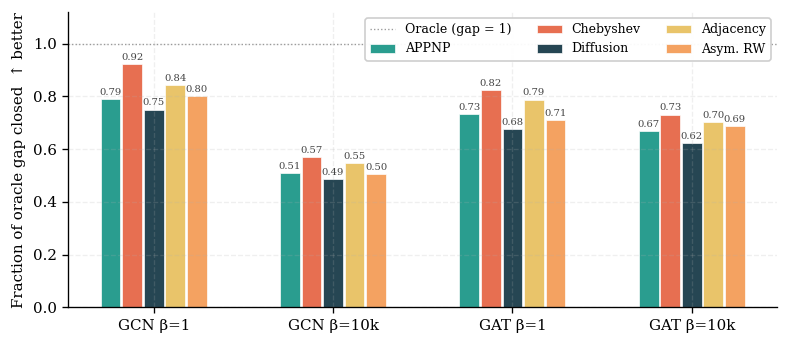

Chebyshev leads across all 4 conditions. Gap-closing drops sharply at high beta (harder federation).


In [7]:
# Figure 3: Downstream gap closure on Cora — grouped bar chart
conditions = ['GCN β=1', 'GCN β=10k', 'GAT β=1', 'GAT β=10k']
gap_data   = {
    'APPNP':     [0.791, 0.508, 0.732, 0.669],
    'Chebyshev': [0.924, 0.570, 0.825, 0.731],
    'Diffusion': [0.750, 0.486, 0.676, 0.623],
    'Adjacency': [0.843, 0.546, 0.788, 0.704],
    'Asym. RW':  [0.801, 0.504, 0.709, 0.687],
}

x     = np.arange(len(conditions))
n     = len(OPS)
width = 0.6 / n
fig, ax = plt.subplots(figsize=FIG_W)

for i, op in enumerate(OPS):
    offset = (i - n/2 + 0.5) * width
    bars = ax.bar(x + offset, gap_data[op], width * 0.92,
                  label=op, color=COLORS[op],
                  edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, gap_data[op]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom', fontsize=6, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel('Fraction of oracle gap closed  ↑ better')
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='#999', linewidth=0.8, linestyle=':', label='Oracle (gap = 1)')
ax.legend(ncol=3, loc='upper right', fontsize=7.5)
fig.tight_layout(pad=0.5)
plt.savefig(f'{OUTDIR}/fig_03_cora_gap_closure.pdf')
plt.savefig(f'{OUTDIR}/fig_03_cora_gap_closure.png', dpi=300)
plt.show()
print('Chebyshev leads across all 4 conditions. Gap-closing drops sharply at high beta (harder federation).')


## Phase 4 — Homophilic Reproduction (Citeseer + Pubmed)

In [8]:
# Citeseer GCN
p4_cs_gcn = pd.DataFrame({
    'Operator':  OPS,
    'Acc_b1':   [0.6656,0.6728,0.6588,0.6692,0.6682],
    'Std_b1':   [0.0142,0.0126,0.0159,0.0112,0.0124],
    'Gap_b1':   [0.511, 0.613, 0.416, 0.556, 0.544],
    'Acc_b10k': [0.6362,0.6428,0.6312,0.6438,0.6394],
    'Std_b10k': [0.0113,0.0144,0.0116,0.0136,0.0122],
    'Gap_b10k': [0.282, 0.340, 0.238, 0.349, 0.310],
})

# Citeseer GAT
p4_cs_gat = pd.DataFrame({
    'Operator':  OPS,
    'Acc_b1':   [0.5898,0.6002,0.5788,0.5982,0.5816],
    'Std_b1':   [0.0550,0.0588,0.0552,0.0558,0.0471],
    'Gap_b1':   [0.556, 0.610, 0.507, 0.598, 0.515],
    'Acc_b10k': [0.5814,0.5922,0.5776,0.5914,0.5818],
    'Std_b10k': [0.0298,0.0246,0.0346,0.0231,0.0252],
    'Gap_b10k': [0.470, 0.515, 0.454, 0.516, 0.469],
})

# Pubmed GCN
p4_pm_gcn = pd.DataFrame({
    'Operator':  OPS,
    'Acc_b1':   [0.7614,0.7712,0.7548,0.7684,0.7668],
    'Std_b1':   [0.0196,0.0233,0.0169,0.0219,0.0206],
    'Gap_b1':   [0.851, 0.970, 0.788, 0.932, 0.927],
    'Acc_b10k': [0.7744,0.7722,0.7638,0.7736,0.7780],
    'Std_b10k': [0.0112,0.0138,0.0137,0.0127,0.0133],
    'Gap_b10k': [0.758, 0.740, 0.658, 0.750, 0.789],
})

# Pubmed GAT
p4_pm_gat = pd.DataFrame({
    'Operator':  OPS,
    'Acc_b1':   [0.7140,0.7266,0.6892,0.7288,0.7344],
    'Std_b1':   [0.0263,0.0158,0.0313,0.0123,0.0124],
    'Gap_b1':   [0.612, 0.751, 0.408, 0.767, 0.808],
    'Acc_b10k': [0.7362,0.7458,0.7208,0.7486,0.7358],
    'Std_b10k': [0.0176,0.0055,0.0253,0.0121,0.0178],
    'Gap_b10k': [0.725, 0.775, 0.642, 0.782, 0.728],
})

print('=== Table 4.1  Citeseer — GCN ===')
display(p4_cs_gcn)
print('\n=== Table 4.2  Citeseer — GAT ===')
display(p4_cs_gat)
print('\n=== Table 4.3  Pubmed — GCN ===')
display(p4_pm_gcn)
print('\n=== Table 4.4  Pubmed — GAT ===')
display(p4_pm_gat)


=== Table 4.1  Citeseer — GCN ===


,Operator,Acc_b1,Std_b1,Gap_b1,Acc_b10k,Std_b10k,Gap_b10k
0,APPNP,0.6656,0.0142,0.5110,0.6362,0.0113,0.2820
1,Chebyshev,0.6728,0.0126,0.6130,0.6428,0.0144,0.3400
2,Diffusion,0.6588,0.0159,0.4160,0.6312,0.0116,0.2380
3,Adjacency,0.6692,0.0112,0.5560,0.6438,0.0136,0.3490
4,Asym. RW,0.6682,0.0124,0.5440,0.6394,0.0122,0.3100



=== Table 4.2  Citeseer — GAT ===


,Operator,Acc_b1,Std_b1,Gap_b1,Acc_b10k,Std_b10k,Gap_b10k
0,APPNP,0.5898,0.0550,0.5560,0.5814,0.0298,0.4700
1,Chebyshev,0.6002,0.0588,0.6100,0.5922,0.0246,0.5150
2,Diffusion,0.5788,0.0552,0.5070,0.5776,0.0346,0.4540
3,Adjacency,0.5982,0.0558,0.5980,0.5914,0.0231,0.5160
4,Asym. RW,0.5816,0.0471,0.5150,0.5818,0.0252,0.4690



=== Table 4.3  Pubmed — GCN ===


,Operator,Acc_b1,Std_b1,Gap_b1,Acc_b10k,Std_b10k,Gap_b10k
0,APPNP,0.7614,0.0196,0.8510,0.7744,0.0112,0.7580
1,Chebyshev,0.7712,0.0233,0.9700,0.7722,0.0138,0.7400
2,Diffusion,0.7548,0.0169,0.7880,0.7638,0.0137,0.6580
3,Adjacency,0.7684,0.0219,0.9320,0.7736,0.0127,0.7500
4,Asym. RW,0.7668,0.0206,0.9270,0.7780,0.0133,0.7890



=== Table 4.4  Pubmed — GAT ===


,Operator,Acc_b1,Std_b1,Gap_b1,Acc_b10k,Std_b10k,Gap_b10k
0,APPNP,0.7140,0.0263,0.6120,0.7362,0.0176,0.7250
1,Chebyshev,0.7266,0.0158,0.7510,0.7458,0.0055,0.7750
2,Diffusion,0.6892,0.0313,0.4080,0.7208,0.0253,0.6420
3,Adjacency,0.7288,0.0123,0.7670,0.7486,0.0121,0.7820
4,Asym. RW,0.7344,0.0124,0.8080,0.7358,0.0178,0.7280


## Phase 5 — OGBN-Arxiv Scalability (Intrinsic Only)

~169K nodes, 128 features, 40 classes, 10 clients.

In [9]:
p5_b1 = pd.DataFrame({
    'Operator':   OPS,
    'MSE':        [0.02630,0.01968,0.01968,0.01913,0.01165],
    'MSE_std':    [0.00024,0.00007,0.00007,0.00006,0.00002],
    'CosSim':     [0.8959, 0.8982, 0.8982, 0.8966, 0.8957],
    'RecovRatio': [0.5252, 0.6446, 0.6446, 0.6546, 0.7898],
    'ConvRate':   [1.00,   0.00,   0.00,   0.00,   0.00],
    'WallTime_s': [33.7,   102.4,  102.3,  2145.2, 2514.1],
})

p5_b10k = pd.DataFrame({
    'Operator':   OPS,
    'MSE':        [0.02631,0.01944,0.01944,0.01884,0.01153],
    'MSE_std':    [0.00001,0.00001,0.00001,0.00001,0.00000],
    'CosSim':     [0.8969, 0.8988, 0.8988, 0.8975, 0.8966],
    'RecovRatio': [0.5245, 0.6486, 0.6486, 0.6594, 0.7916],
    'ConvRate':   [1.00,   0.00,   0.00,   0.00,   0.00],
    'WallTime_s': [37.8,   117.0,  116.8,  2464.6, 2434.9],
})

p5_eff = pd.DataFrame({
    'Operator':   OPS,
    'MSE_b10k':   [0.02631,0.01944,0.01944,0.01884,0.01153],
    'WallTime_s': [37.8,   117.0,  116.8,  2464.6, 2434.9],
    'MSExWT':     [0.994,  2.274,  2.270,  46.4,   28.1],
})

print('=== Table 5.1  OGBN-Arxiv beta=1 ===')
display(p5_b1)
print('\n=== Table 5.2  OGBN-Arxiv beta=10000 ===')
display(p5_b10k)
print('\n=== Table 5.3  Efficiency vs Quality (beta=10000) ===')
display(p5_eff.sort_values('MSExWT'))


=== Table 5.1  OGBN-Arxiv beta=1 ===


,Operator,MSE,MSE_std,CosSim,RecovRatio,ConvRate,WallTime_s
0,APPNP,0.0263,0.0002,0.8959,0.5252,1.0000,33.7000
1,Chebyshev,0.0197,0.0001,0.8982,0.6446,0.0000,102.4000
2,Diffusion,0.0197,0.0001,0.8982,0.6446,0.0000,102.3000
3,Adjacency,0.0191,0.0001,0.8966,0.6546,0.0000,2145.2000
4,Asym. RW,0.0117,0.0000,0.8957,0.7898,0.0000,2514.1000



=== Table 5.2  OGBN-Arxiv beta=10000 ===


,Operator,MSE,MSE_std,CosSim,RecovRatio,ConvRate,WallTime_s
0,APPNP,0.0263,0.0000,0.8969,0.5245,1.0000,37.8000
1,Chebyshev,0.0194,0.0000,0.8988,0.6486,0.0000,117.0000
2,Diffusion,0.0194,0.0000,0.8988,0.6486,0.0000,116.8000
3,Adjacency,0.0188,0.0000,0.8975,0.6594,0.0000,2464.6000
4,Asym. RW,0.0115,0.0000,0.8966,0.7916,0.0000,2434.9000



=== Table 5.3  Efficiency vs Quality (beta=10000) ===


,Operator,MSE_b10k,WallTime_s,MSExWT
0,APPNP,0.0263,37.8000,0.9940
2,Diffusion,0.0194,116.8000,2.2700
1,Chebyshev,0.0194,117.0000,2.2740
4,Asym. RW,0.0115,2434.9000,28.1000
3,Adjacency,0.0188,2464.6000,46.4000


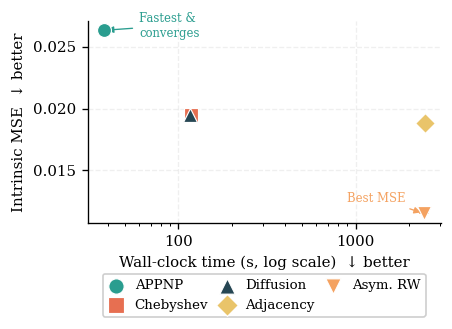

APPNP: fast + converges. Asym. RW: best quality, 66x slower. Diffusion=Chebyshev at this scale.


In [10]:
# Figure 2: Quality-efficiency trade-off on OGBN-Arxiv (log x-axis)
mse_vals = p5_b10k['MSE'].values
wt_vals  = p5_b10k['WallTime_s'].values
mse_std  = p5_b10k['MSE_std'].values

fig, ax = plt.subplots(figsize=FIG_S)

for op, mx, ms, wt in zip(OPS, mse_vals, mse_std, wt_vals):
    ax.errorbar(wt, mx, yerr=ms, fmt='none',
                ecolor=COLORS[op], elinewidth=1.0, capsize=3, alpha=0.6)
    ax.scatter(wt, mx, color=COLORS[op], marker=MARKERS[op],
               s=70, zorder=4, edgecolors='white', linewidths=0.7,
               label=op)

ax.set_xscale('log')
ax.set_xlabel('Wall-clock time (s, log scale)  ↓ better')
ax.set_ylabel('Intrinsic MSE  ↓ better')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

# Pareto-front annotation
ax.annotate('Fastest &\nconverges', xy=(37.8, 0.02631),
            xytext=(60, 0.0258), fontsize=7, color=COLORS['APPNP'],
            arrowprops=dict(arrowstyle='-|>', color=COLORS['APPNP'],
                            lw=0.8, mutation_scale=8), ha='left')
ax.annotate('Best MSE', xy=(2434.9, 0.01153),
            xytext=(900, 0.0125), fontsize=7, color=COLORS['Asym. RW'],
            arrowprops=dict(arrowstyle='-|>', color=COLORS['Asym. RW'],
                            lw=0.8, mutation_scale=8), ha='left')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=8, markerscale=1.1,
          handlelength=1.2, columnspacing=0.8)
fig.subplots_adjust(bottom=0.28)

plt.savefig(f'{OUTDIR}/fig_02_ogbn_efficiency.pdf')
plt.savefig(f'{OUTDIR}/fig_02_ogbn_efficiency.png', dpi=300)
plt.show()
print('APPNP: fast + converges. Asym. RW: best quality, 66x slower. Diffusion=Chebyshev at this scale.')


## Phase 6 — Heterophily Stress Test (Texas + Wisconsin)

GCN backbone, β = 10 000 only.

In [11]:
# Only 4 operators tested here (no Chebyshev or Asym. RW)
ops6 = ['Adjacency', 'Diffusion', 'APPNP', 'Zero-Hop']

p6_texas = pd.DataFrame({
    'Operator': ops6,
    'Acc_mean': [0.7405, 0.7351, 0.7243, 0.6973],
    'Acc_std':  [0.0582, 0.0626, 0.0649, 0.0432],
    'Gain_vs_ZeroHop': [0.0432, 0.0378, 0.0270, 0.0],
})

p6_wisc = pd.DataFrame({
    'Operator': ops6,
    'Acc_mean': [0.7412, 0.7882, 0.7725, 0.7725],
    'Acc_std':  [0.0260, 0.0487, 0.0422, 0.0440],
    'Gain_vs_ZeroHop': [-0.0313, 0.0157, 0.0000, 0.0],
})

print('=== Table 6.1  Texas (GCN, beta=10000) ===')
display(p6_texas.sort_values('Acc_mean', ascending=False))
print('\n=== Table 6.2  Wisconsin (GCN, beta=10000) ===')
display(p6_wisc.sort_values('Acc_mean', ascending=False))


=== Table 6.1  Texas (GCN, beta=10000) ===


,Operator,Acc_mean,Acc_std,Gain_vs_ZeroHop
0,Adjacency,0.7405,0.0582,0.0432
1,Diffusion,0.7351,0.0626,0.0378
2,APPNP,0.7243,0.0649,0.0270
3,Zero-Hop,0.6973,0.0432,0.0000



=== Table 6.2  Wisconsin (GCN, beta=10000) ===


,Operator,Acc_mean,Acc_std,Gain_vs_ZeroHop
1,Diffusion,0.7882,0.0487,0.0157
2,APPNP,0.7725,0.0422,0.0000
3,Zero-Hop,0.7725,0.0440,0.0000
0,Adjacency,0.7412,0.0260,-0.0313


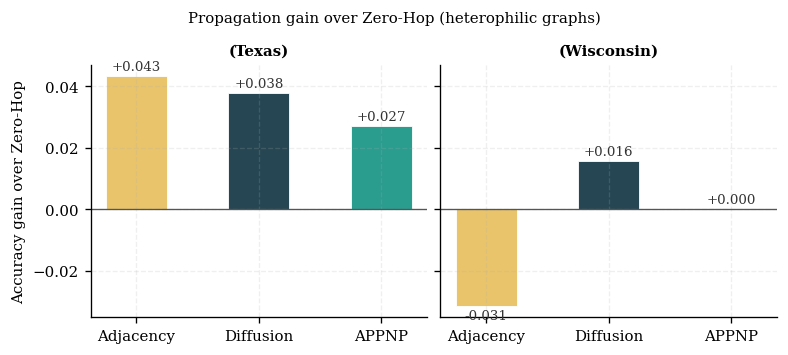

Texas: all operators help. Wisconsin: Adjacency hurts (-3.1pp), Diffusion helps (+1.6pp).


In [12]:
# Figure 12: Heterophily gain over zero-hop (two panels)
ops_plot = ['Adjacency', 'Diffusion', 'APPNP']
texas_gain = [0.0432, 0.0378, 0.0270]
wisc_gain  = [-0.0313, 0.0157, 0.0000]

fig, axes = plt.subplots(1, 2, figsize=FIG_W, sharey=True)
bar_colors = [COLORS[o] for o in ops_plot]

for ax, gains, title in zip(axes, [texas_gain, wisc_gain], ['Texas', 'Wisconsin']):
    bars = ax.bar(ops_plot, gains,
                  color=bar_colors, edgecolor='white', linewidth=0.5, width=0.5)
    ax.axhline(0, color='#555', linewidth=0.8)
    ax.set_title(f'({title})')
    ax.set_ylabel('Accuracy gain over Zero-Hop' if ax == axes[0] else '')
    for bar, g in zip(bars, gains):
        va = 'bottom' if g >= 0 else 'top'
        offset = 0.001 if g >= 0 else -0.001
        ax.text(bar.get_x() + bar.get_width()/2, g + offset,
                f'{g:+.3f}', ha='center', va=va, fontsize=8, color='#333')

fig.suptitle('Propagation gain over Zero-Hop (heterophilic graphs)', fontsize=9, y=1.01)
fig.tight_layout(pad=0.5)
plt.savefig(f'{OUTDIR}/fig_12_heterophily_gain.pdf')
plt.savefig(f'{OUTDIR}/fig_12_heterophily_gain.png', dpi=300)
plt.show()
print('Texas: all operators help. Wisconsin: Adjacency hurts (-3.1pp), Diffusion helps (+1.6pp).')


## Cross-Dataset Summary

In [13]:
# Table S1 — Best operator per condition
s1 = pd.DataFrame({
    'Dataset':  ['Cora','Cora','Cora','Cora',
                 'Citeseer','Citeseer','Citeseer','Citeseer',
                 'Pubmed','Pubmed','Pubmed','Pubmed',
                 'Texas','Wisconsin'],
    'Backbone': ['GCN','GCN','GAT','GAT']*3 + ['GCN','GCN'],
    'Beta':     [1,10000,1,10000]*3 + [10000,10000],
    'BestOp':   ['Chebyshev','Chebyshev','Chebyshev','Chebyshev',
                 'Chebyshev','Adjacency','Chebyshev','Adjacency',
                 'Chebyshev','Asym. RW','Asym. RW','Adjacency',
                 'Adjacency','Diffusion'],
    'BestAcc':  [0.7840,0.7205,0.7006,0.6898,
                 0.6728,0.6438,0.6002,0.5914,
                 0.7712,0.7780,0.7344,0.7486,
                 0.7405,0.7882],
    'GapClosed':[0.924,0.570,0.825,0.731,
                 0.613,0.349,0.610,0.516,
                 0.970,0.789,0.808,0.782,
                 None, None],
})
print('=== Table S1  Best Operator per Dataset x Backbone x Beta ===')
display(s1)

# Table S2 — Average rankings (homophilic)
s2 = pd.DataFrame({
    'Rank':       [1,2,3,4,5],
    'Operator':   ['Chebyshev','Adjacency','Asym. RW','APPNP','Diffusion'],
    'AvgAcc_GCN': [0.740,0.736,0.735,0.733,0.726],
    'AvgAcc_GAT': [0.668,0.660,0.661,0.657,0.644],
    'AvgGapClosed':[0.736,0.715,0.714,0.695,0.643],
})
print('\n=== Table S2  Average Operator Rankings (Homophilic Datasets) ===')
display(s2)

# Table S3 — Intrinsic MSE ranking (Cora, beta=10000)
s3 = pd.DataFrame({
    'Rank':       [1,2,3,4,5,6],
    'Operator':   ['Heat Kernel','APPNP','Chebyshev','Diffusion','Adjacency','Asym. RW'],
    'MSE':        [0.01231,0.01299,0.01325,0.01334,0.01400,0.01602],
    'CosSim':     [0.2068, 0.2183, 0.2386, 0.2189, 0.2237, 0.2196],
    'RecovRatio': [0.0343,-0.0169,-0.0373,-0.0444,-0.0962,-0.2541],
})
print('\n=== Table S3  Intrinsic MSE Ranking (Cora, beta=10000) ===')
display(s3)

# Table S4 — Intrinsic vs downstream rank discrepancy
s4 = pd.DataFrame({
    'Operator':        ['APPNP','Chebyshev','Diffusion','Adjacency','Asym. RW'],
    'IntrinsicRank':   [1,3,4,5,6],
    'DownstreamRank':  [4,1,5,2,3],
    'Discrepancy':     ['-3','↑+2','-1','↑+3','↑+3'],
})
print('\n=== Table S4  Intrinsic vs Downstream Rank Decoupling (Cora) ===')
display(s4)
print('\nKey: intrinsic MSE is a poor predictor of downstream accuracy.')


=== Table S1  Best Operator per Dataset x Backbone x Beta ===


,Dataset,Backbone,Beta,BestOp,BestAcc,GapClosed
0,Cora,GCN,1,Chebyshev,0.7840,0.9240
1,Cora,GCN,10000,Chebyshev,0.7205,0.5700
2,Cora,GAT,1,Chebyshev,0.7006,0.8250
3,Cora,GAT,10000,Chebyshev,0.6898,0.7310
4,Citeseer,GCN,1,Chebyshev,0.6728,0.6130
5,Citeseer,GCN,10000,Adjacency,0.6438,0.3490
6,Citeseer,GAT,1,Chebyshev,0.6002,0.6100
7,Citeseer,GAT,10000,Adjacency,0.5914,0.5160
8,Pubmed,GCN,1,Chebyshev,0.7712,0.9700
9,Pubmed,GCN,10000,Asym. RW,0.7780,0.7890



=== Table S2  Average Operator Rankings (Homophilic Datasets) ===


,Rank,Operator,AvgAcc_GCN,AvgAcc_GAT,AvgGapClosed
0,1,Chebyshev,0.7400,0.6680,0.7360
1,2,Adjacency,0.7360,0.6600,0.7150
2,3,Asym. RW,0.7350,0.6610,0.7140
3,4,APPNP,0.7330,0.6570,0.6950
4,5,Diffusion,0.7260,0.6440,0.6430



=== Table S3  Intrinsic MSE Ranking (Cora, beta=10000) ===


,Rank,Operator,MSE,CosSim,RecovRatio
0,1,Heat Kernel,0.0123,0.2068,0.0343
1,2,APPNP,0.0130,0.2183,-0.0169
2,3,Chebyshev,0.0132,0.2386,-0.0373
3,4,Diffusion,0.0133,0.2189,-0.0444
4,5,Adjacency,0.0140,0.2237,-0.0962
5,6,Asym. RW,0.0160,0.2196,-0.2541



=== Table S4  Intrinsic vs Downstream Rank Decoupling (Cora) ===


,Operator,IntrinsicRank,DownstreamRank,Discrepancy
0,APPNP,1,4,-3
1,Chebyshev,3,1,↑+2
2,Diffusion,4,5,-1
3,Adjacency,5,2,↑+3
4,Asym. RW,6,3,↑+3



Key: intrinsic MSE is a poor predictor of downstream accuracy.


## Main Paper Figures

Paper-ready figures exported to `experiments/propagator_eval/figures/`.

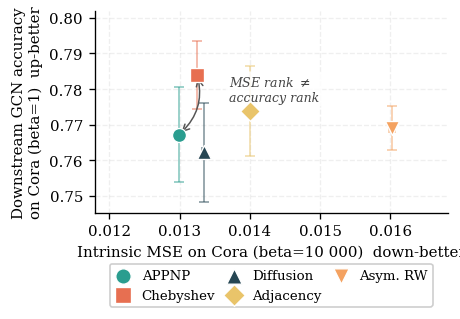

APPNP: best MSE (leftmost), 4th on accuracy.  Chebyshev: 3rd on MSE, 1st on accuracy.


In [14]:
# Figure 1 — Intrinsic MSE vs downstream GCN accuracy (Cora)
# Proves the central decoupling claim.

mse_mean = np.array([0.01299, 0.01325, 0.01334, 0.01400, 0.01602])
mse_std  = np.array([0.00002, 0.00002, 0.00002, 0.00002, 0.00004])
acc_mean = np.array([0.7672,  0.7840,  0.7622,  0.7738,  0.7690])
acc_std  = np.array([0.0133,  0.0096,  0.0139,  0.0127,  0.0062])

fig, ax = plt.subplots(figsize=FIG_S)

for op, mx, ms, ay, ys in zip(OPS, mse_mean, mse_std, acc_mean, acc_std):
    ax.errorbar(mx, ay, xerr=ms, yerr=ys, fmt='none',
                ecolor=COLORS[op], elinewidth=1.0, capsize=3, alpha=0.55,
                zorder=2)
    ax.scatter(mx, ay, color=COLORS[op], marker=MARKERS[op],
               s=70, zorder=4, edgecolors='white', linewidths=0.8,
               label=op)

# Double-headed arc between APPNP and Chebyshev
ax.annotate('', xy=(0.01299, 0.7672), xytext=(0.01325, 0.7840),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=0.9,
                            mutation_scale=10,
                            connectionstyle='arc3,rad=-0.30'))
ax.text(0.01370, 0.7800, 'MSE rank $\\neq$\naccuracy rank',
        fontsize=7.5, color='#444', ha='left', va='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))

ax.set_xlim(mse_mean.min()-0.0012, mse_mean.max()+0.0008)
ax.set_ylim(acc_mean.min()-acc_std.max()-0.003,
            acc_mean.max()+acc_std.max()+0.004)
ax.set_xlabel('Intrinsic MSE on Cora (beta=10 000)  down-better')
ax.set_ylabel('Downstream GCN accuracy\non Cora (beta=1)  up-better')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=8, markerscale=1.1,
          handlelength=1.2, columnspacing=0.8)
fig.subplots_adjust(bottom=0.28)

plt.savefig(f'{OUTDIR}/fig_01_intrinsic_vs_downstream.pdf')
plt.savefig(f'{OUTDIR}/fig_01_intrinsic_vs_downstream.png', dpi=300)
plt.show()
print('APPNP: best MSE (leftmost), 4th on accuracy.  Chebyshev: 3rd on MSE, 1st on accuracy.')


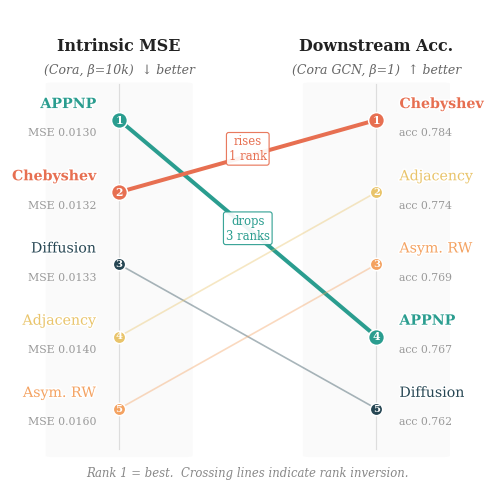

APPNP: rank-1 on intrinsic MSE → rank-4 downstream (drops 3).
Chebyshev: rank-2 on MSE → rank-1 downstream (rises 1).
Adjacency + Asym. RW both rise significantly despite poor intrinsic MSE.


In [15]:
# Figure 1b — Slope chart: intrinsic MSE rank vs downstream accuracy rank
# Crossing lines make rank inversions immediately visible.
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

mse_rank = {'APPNP': 1, 'Chebyshev': 2, 'Diffusion': 3, 'Adjacency': 4, 'Asym. RW': 5}
mse_val  = {'APPNP': 0.01299, 'Chebyshev': 0.01325, 'Diffusion': 0.01334,
            'Adjacency': 0.01400, 'Asym. RW': 0.01602}
acc_rank = {'Chebyshev': 1, 'Adjacency': 2, 'Asym. RW': 3, 'APPNP': 4, 'Diffusion': 5}
acc_val  = {'APPNP': 0.767, 'Chebyshev': 0.784, 'Diffusion': 0.762,
            'Adjacency': 0.774, 'Asym. RW': 0.769}

def ry(r): return 6 - r   # rank 1 → y=5 (top), rank 5 → y=1 (bottom)

XL, XR = 0.22, 0.78
Y_TOP, Y_BOT = 5.55, 0.55
DOT_BIG, DOT_SML = 90, 55

fig, ax = plt.subplots(figsize=(4.2, 4.0))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 6.5)

# Subtle column backgrounds
for xc in (XL, XR):
    ax.add_patch(mpatches.FancyBboxPatch(
        (xc - 0.14, Y_BOT - 0.2), 0.28, Y_TOP - Y_BOT + 0.15,
        boxstyle='round,pad=0.02', fc='#aaaaaa', ec='none', alpha=0.06, zorder=0))

# Connecting lines (behind dots)
for op in OPS:
    y1, y2 = ry(mse_rank[op]), ry(acc_rank[op])
    highlight = op in ('APPNP', 'Chebyshev')
    ax.plot([XL, XR], [y1, y2], color=COLORS[op],
            lw=2.4 if highlight else 1.0,
            alpha=1.0 if highlight else 0.40,
            solid_capstyle='round', zorder=2)

# Dots with rank numbers inside
for op in OPS:
    y1, y2 = ry(mse_rank[op]), ry(acc_rank[op])
    highlight = op in ('APPNP', 'Chebyshev')
    sz = DOT_BIG if highlight else DOT_SML
    for xc, yc in [(XL, y1), (XR, y2)]:
        ax.scatter(xc, yc, color=COLORS[op], s=sz, zorder=5,
                   edgecolors='white', linewidths=0.9)
    for xc, yc, rk in [(XL, y1, mse_rank[op]), (XR, y2, acc_rank[op])]:
        ax.text(xc, yc, str(rk), ha='center', va='center',
                fontsize=6 if sz == DOT_SML else 6.5,
                color='white', fontweight='bold', zorder=6)

# Left labels (sorted by MSE rank)
for op in OPS:
    y = ry(mse_rank[op])
    highlight = op in ('APPNP', 'Chebyshev')
    ax.text(XL - 0.05, y + 0.22, op, ha='right', va='center', fontsize=8.5,
            color=COLORS[op], fontweight='bold' if highlight else 'normal',
            path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])
    ax.text(XL - 0.05, y - 0.18, f"MSE {mse_val[op]:.4f}",
            ha='right', va='center', fontsize=6.5, color='#999')

# Right labels (sorted by acc rank)
for op in OPS:
    y = ry(acc_rank[op])
    highlight = op in ('APPNP', 'Chebyshev')
    ax.text(XR + 0.05, y + 0.22, op, ha='left', va='center', fontsize=8.5,
            color=COLORS[op], fontweight='bold' if highlight else 'normal',
            path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])
    ax.text(XR + 0.05, y - 0.18, f"acc {acc_val[op]:.3f}",
            ha='left', va='center', fontsize=6.5, color='#999')

# Rank-change callout badges
ax.annotate('drops\n3 ranks', xy=(0.50, (ry(1) + ry(4)) / 2),
            fontsize=7, color=COLORS['APPNP'], ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec=COLORS['APPNP'], lw=0.7, alpha=0.92))
ax.annotate('rises\n1 rank', xy=(0.50, (ry(2) + ry(1)) / 2 + 0.1),
            fontsize=7, color=COLORS['Chebyshev'], ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec=COLORS['Chebyshev'], lw=0.7, alpha=0.92))

# Column headers
ax.text(XL, Y_TOP + 0.35, 'Intrinsic MSE',
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#222')
ax.text(XL, Y_TOP + 0.05, '(Cora, β=10k)  ↓ better',
        ha='center', va='bottom', fontsize=7.5, color='#666', style='italic')
ax.text(XR, Y_TOP + 0.35, 'Downstream Acc.',
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#222')
ax.text(XR, Y_TOP + 0.05, '(Cora GCN, β=1)  ↑ better',
        ha='center', va='bottom', fontsize=7.5, color='#666', style='italic')

for xc in (XL, XR):
    ax.plot([xc, xc], [Y_BOT - 0.1, Y_TOP - 0.05], color='#ddd', lw=0.7, zorder=1)

ax.text(0.50, Y_BOT - 0.35, 'Rank 1 = best.  Crossing lines indicate rank inversion.',
        ha='center', va='top', fontsize=7, style='italic', color='#888')

fig.tight_layout(pad=0.3)
plt.savefig(f'{OUTDIR}/fig_01b_slope_chart.pdf')
plt.savefig(f'{OUTDIR}/fig_01b_slope_chart.png', dpi=300)
plt.show()
print('APPNP: rank-1 on intrinsic MSE → rank-4 downstream (drops 3).')
print('Chebyshev: rank-2 on MSE → rank-1 downstream (rises 1).')
print('Adjacency + Asym. RW both rise significantly despite poor intrinsic MSE.')
